# LLM Distillation

## Design
- **Topic**：Fictional Programming Language `Floq`
- **Student**：`Qwen/Qwen2.5-0.5B-Instruct`
- **Distillation Method**：Offline SFT Distillation
- **Evaluate**：Comparison of Accuracy on Floq Q&A Before and After Distillation

## Floq Rules
```
- Variable Declaration:     val x := 42
- Function Definition：     fn add(a, b) => a + b
- Conditional Statements:    when x > 0 { ... } else { ... }
- Loop:             loop 10 times { ... }
- Print / Output:       shout("hello")
- Types:            num, str, bool, list
- Comments:           ## This is a comment
- Lists:            val xs := [1, 2, 3]
- Indexing:           xs~0
- String Concatenation:    "hello" ++ " world"
```


---
## Step 0：Install Dependencies

In [1]:
!pip install transformers==4.44.0 peft==0.12.0 trl==0.10.1 \
             datasets accelerate bitsandbytes openai \
             sentencepiece protobuf rouge-score -q
print("Complete")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.1/280.1 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 20.9 MB/s eta 0:00:00
Complete


---
## Step 1：API Key

In [2]:
import os
import torch
from google.colab import userdata

try:
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
    print("API read")
except:
    print("API not read")

# GPU Check
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    vram_gb = gpu.total_memory / 1e9
    print(f" GPU: {gpu.name}  VRAM: {vram_gb:.1f} GB")
else:
    print("No GPU detected.")

API read
 GPU: NVIDIA A100-SXM4-40GB  VRAM: 42.4 GB


---
## Step 2：Define Floq & Teacher Data Generation

In [3]:
from openai import OpenAI
import json
import time
import random
from pathlib import Path

# Floq Rules
FLOQ_SPEC = """
You are an expert in the Floq programming language. Floq is a fictional language with these rules:

SYNTAX RULES:
1. Variable declaration:   val <name> := <value>
2. Function definition:    fn <name>(<params>) => <body>
3. Conditional:            when <cond> { <then> } else { <else> }
4. Loop:                   loop <n> times { <body> }
5. Print:                  shout(<expr>)
6. Types:                  num (numbers), str (strings), bool (true/false), list
7. Comments:               ## this is a comment
8. List literal:           [1, 2, 3]
9. List indexing:          xs~0  (tilde ~ replaces brackets)
10. String concat:         "hello" ++ " world"
11. Boolean ops:           and, or, not
12. Return value:          last expression in fn body is returned automatically
13. Multiple statements:   separated by newlines or semicolons
14. No semicolons required (optional)

EXAMPLES:
```floq
## Compute factorial
fn factorial(n) =>
  when n <= 1 { 1 } else { n * factorial(n - 1) }

val result := factorial(5)
shout(result)  ## prints 120
```

```floq
## List operations
val nums := [10, 20, 30]
shout(nums~0)        ## prints 10
shout(nums~1 + 5)    ## prints 25
```

```floq
## String operations
val greeting := "Hello" ++ ", " ++ "Floq!"
shout(greeting)      ## prints Hello, Floq!
```

Always respond with correct Floq syntax. Never use Python, JavaScript or other language syntax.
"""

print("Floq Definition Complete")

Floq Definition Complete


In [4]:
# Constructing Problem Templates
QUESTION_TEMPLATES = [
    # Grammar
    "How do you declare a variable named {var} with value {val} in Floq?",
    "Write a Floq function that {task}.",
    "What is the correct Floq syntax to print {thing}?",
    "How do you write a conditional in Floq that checks if {cond}?",
    "Write a Floq loop that {loop_task}.",
    "How do you access the {nth} element of a list in Floq?",
    "How do you concatenate two strings in Floq?",
    "What keyword does Floq use instead of 'print' or 'console.log'?",
    # Code Comprehension
    "What does this Floq code do?\n```floq\n{code_snippet}\n```",
    "Is this valid Floq code? Explain why or why not:\n```\n{invalid_code}\n```",
    # General
    "Write a complete Floq program to {full_task}.",
    "What are the data types available in Floq?",
    "How does function definition in Floq differ from Python?",
    "In Floq, how do you write comments?",
    "What symbol does Floq use for list indexing instead of []?",
]

TEMPLATE_VARS = {
    "var":         ["x", "count", "name", "total", "score", "items"],
    "val":         ["42", "3.14", "\"Alice\"", "true", "[1,2,3]"],
    "task":        ["adds two numbers", "returns the max of two values",
                    "computes the square of a number", "checks if a number is even",
                    "reverses a string by concatenation", "multiplies all numbers in a list"],
    "thing":       ["the value of a variable", "a greeting message", "the result of 2+2"],
    "cond":        ["x is greater than 10", "a string equals 'hello'", "a number is negative"],
    "loop_task":   ["prints numbers 1 to 5", "shouts 'hi' three times", "runs a block 7 times"],
    "nth":         ["first", "second", "third", "last"],
    "code_snippet":["val x := 5\nval y := 3\nshout(x + y)",
                    "fn double(n) => n * 2\nshout(double(7))",
                    "val words := [\"hi\", \"there\"]\nshout(words~0 ++ \" \" ++ words~1)"],
    "invalid_code":["let x = 5  ## Python style", "print('hello')  ## wrong keyword",
                    "x[0]  ## wrong indexing"],
    "full_task":   ["compute the sum of numbers from 1 to 10",
                    "define a greeting function and call it",
                    "find the maximum of three numbers"],
}

def generate_question():
    tmpl = random.choice(QUESTION_TEMPLATES)
    for key, vals in TEMPLATE_VARS.items():
        if "{" + key + "}" in tmpl:
            tmpl = tmpl.replace("{" + key + "}", random.choice(vals))
    return tmpl

# Preview
print("Sample Problem：")
for _ in range(5):
    print(f"  • {generate_question()}")

Sample Problem：
  • How do you access the first element of a list in Floq?
  • How do you concatenate two strings in Floq?
  • Write a complete Floq program to compute the sum of numbers from 1 to 10.
  • How do you access the first element of a list in Floq?
  • Write a Floq function that returns the max of two values.


In [5]:
# GPT-4o-mini Generates Training Data as a Teacher
client = OpenAI()
from tqdm.auto import tqdm

def teacher_generate(question: str) -> str:
    """Teacher generates the answer."""
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        max_tokens=512,
        messages=[
            {"role": "system", "content": FLOQ_SPEC},
            {"role": "user", "content": question}
        ]
    )
    return response.choices[0].message.content

# Training Set (200) + Test Set (30)
TRAIN_SIZE = 200
TEST_SIZE = 30
DATA_PATH = Path("/content/floq_data")
DATA_PATH.mkdir(exist_ok=True)

def generate_dataset(size: int, filename: str, desc: str):
    data = []
    print(f"\n Generate{desc}（{size} items）...")
    for i in tqdm(range(size), desc=desc):
        q = generate_question()
        try:
            a = teacher_generate(q)
            data.append({"instruction": q, "output": a, "source": "teacher_gpt-4o-mini"})
        except Exception as e:
            print(f" Item{i}failed: {e}")
            continue
        time.sleep(0.1)

    path = DATA_PATH / filename
    with open(path, "w") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print(f" Saved to {path}（{len(data)} item）")
    return data

train_data = generate_dataset(TRAIN_SIZE, "train.json", "Training Set")
test_data  = generate_dataset(TEST_SIZE,  "test.json",  "Test Set")

# Preview
print("\n Training Data Samples：")
sample = train_data[0]
print(f"Q: {sample['instruction']}")
print(f"A: {sample['output'][:300]}...")


 GenerateTraining Set（200 items）...


Training Set:   0%|          | 0/200 [00:00<?, ?it/s]

 Saved to /content/floq_data/train.json（200 item）

 GenerateTest Set（30 items）...


Test Set:   0%|          | 0/30 [00:00<?, ?it/s]

 Saved to /content/floq_data/test.json（30 item）

 Training Data Samples：
Q: Write a Floq function that reverses a string by concatenation.
A: ```floq
## Function to reverse a string
fn reverseString(s) =>
  val reversed := ""
  loop s.length() times {
    val index := s.length() - 1 - _  ## Using "_" for loop variable
    reversed := reversed ++ s~index
  }
  reversed

val result := reverseString("Floq")
shout(result)  ## prints qolF
```...


---
## Step 3：Evaluate Baseline

In [6]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"

print(f"Load Student Model: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token

baseline_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
baseline_model.eval()
print("Model loaded successfully.")

#
mem = torch.cuda.memory_allocated() / 1e9
print(f"VRAM Usage: {mem:.2f} GB")

Load Student Model: Qwen/Qwen2.5-0.5B-Instruct


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Model loaded successfully.
VRAM Usage: 1.20 GB


In [7]:
from tqdm.auto import tqdm

def student_generate(model, tokenizer, question: str, max_new_tokens=256) -> str:
    """Generate a response using the Student model."""
    messages = [
        {"role": "system", "content": "You are a helpful programming assistant."},
        {"role": "user",   "content": question}
    ]
    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )
    generated = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated, skip_special_tokens=True)

# Eval Func: Detects the hit rate of the "Floq" keyword in the output.
FLOQ_KEYWORDS = [
    ":=", "fn ", "=> ", "when ", "shout(", "loop ", "times",
    " ~", "val ", " ++ ", "## "
]

def floq_score(text: str) -> float:
    """Calculate the coverage (0–1) of Floq syntax keywords within the text."""
    hits = sum(1 for kw in FLOQ_KEYWORDS if kw in text)
    return hits / len(FLOQ_KEYWORDS)

def evaluate(model, tokenizer, test_data, n=30, label="Model"):
    """Evaluate Floq syntax hit rate on the test set."""
    scores = []
    keyword_counts = {kw: 0 for kw in FLOQ_KEYWORDS}

    print(f"\n Evaluate {label}（{n} test items）...")
    for i, item in enumerate(tqdm(test_data[:n], desc=f"Evaluate {label}")):
        pred = student_generate(model, tokenizer, item["instruction"])
        score = floq_score(pred)
        scores.append(score)
        for kw in FLOQ_KEYWORDS:
            if kw in pred:
                keyword_counts[kw] += 1

    avg = sum(scores) / len(scores)
    print(f"\n {label} Floq Syntax Hit Rate: {avg:.4f} ({avg*100:.1f}%)")
    print("  Keyword Hit Count（Perfect Score=" + str(n) + "）:")
    for kw, cnt in sorted(keyword_counts.items(), key=lambda x: -x[1]):
        bar = "█" * int(cnt/n*20)
        print(f"    {kw:8s} {bar:20s} {cnt}/{n}")
    return avg, scores, keyword_counts

#  Baseline
baseline_avg, baseline_scores, baseline_kw = evaluate(
    baseline_model, tokenizer, test_data, label="Baseline（Undistilled）"
)


 Evaluate Baseline（Undistilled）（30 test items）...


Evaluate Baseline（Undistilled）:   0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:589: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarni


 Baseline（Undistilled） Floq Syntax Hit Rate: 0.0515 (5.2%)
  Keyword Hit Count（Perfect Score=30）:
    ##       ███                  5/30
    :=       ██                   4/30
    shout(   ██                   3/30
    val      ██                   3/30
    when     █                    2/30
    fn                            0/30
    =>                            0/30
    loop                          0/30
    times                         0/30
     ~                            0/30
     ++                           0/30


In [8]:
# Preview
print(" Baseline Sample Answer:\n")
floq_questions = [
    "How do you declare a variable in Floq?",
    "What keyword does Floq use for printing?",
    "Write a Floq function that adds two numbers.",
]
for q in floq_questions:
    ans = student_generate(baseline_model, tokenizer, q, max_new_tokens=150)
    print(f"Q: {q}")
    print(f"A: {ans[:300]}")
    print("-" * 60)

 Baseline Sample Answer:

Q: How do you declare a variable in Floq?
A: In Floq, you can declare variables using the `var` keyword followed by the name of the variable and its data type (e.g., integer, float, string). Here's an example:

```floq
var myVariable: integer;
```

This declares a variable named `myVariable` that is of type `integer`. You can then assign value
------------------------------------------------------------
Q: What keyword does Floq use for printing?
A: I'm sorry, but I don't have enough information to determine which specific keyword Floq uses for printing. Without more context or details about the product or company in question, it's difficult to provide an accurate answer. Could you please provide me with more information about Floq and its prod
------------------------------------------------------------
Q: Write a Floq function that adds two numbers.
A: Certainly! Here's an example of a simple Floq function in Python:

```python
def add_numbers(a, b):
    ret

---
## Step 4：LoRA Fine-tuning

In [9]:
import gc
import torch
from datasets import Dataset
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig
from transformers import AutoModelForCausalLM, TrainingArguments, DataCollatorForSeq2Seq

# Release VRAM
try:
    del baseline_model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()
print("Released")

# Reload Model
train_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
train_model.config.use_cache = False
print("Training model loaded successfully.")

Released
Training model loaded successfully.


In [10]:
# LoRA Config
lora_config = LoraConfig(
    r=32,                          # LoRA rank
    lora_alpha=64,                 # Scaling factor
    target_modules=[               # Layers to inject LoRA
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

train_model = get_peft_model(train_model, lora_config)
train_model.print_trainable_parameters()

trainable params: 17,596,416 || all params: 511,629,184 || trainable%: 3.4393


In [11]:
# Convert QA pairs into a conversational format.
def format_sample(item):
    """Format the training data into a conversational format."""
    messages = [
        {"role": "system",    "content": "You are a Floq programming language expert."},
        {"role": "user",      "content": item["instruction"]},
        {"role": "assistant", "content": item["output"]}
    ]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text}

train_dataset = Dataset.from_list(train_data).map(format_sample)
print(f" Training set preparation complete.：{len(train_dataset)} items")
print("\nSample Data (Formatted)：")
print(train_dataset[0]["text"][:400], "...")

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

 Training set preparation complete.：200 items

Sample Data (Formatted)：
<|im_start|>system
You are a Floq programming language expert.<|im_end|>
<|im_start|>user
Write a Floq function that reverses a string by concatenation.<|im_end|>
<|im_start|>assistant
```floq
## Function to reverse a string
fn reverseString(s) =>
  val reversed := ""
  loop s.length() times {
    val index := s.length() - 1 - _  ## Using "_" for loop variable
    reversed := reversed ++ s~index
  ...


In [12]:
# Training Config
OUTPUT_DIR = "/content/floq_student_lora"

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,   # batch_size=16
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    logging_steps=10,
    save_steps=50,
    save_total_limit=2,
    fp16=True,
    optim="paged_adamw_32bit",
    dataset_text_field="text",
    max_seq_length=512,
    report_to="none",
    packing=False,
)

trainer = SFTTrainer(
    model=train_model,
    args=training_args,
    train_dataset=train_dataset,
    tokenizer=tokenizer,
)

print(" Trainer initialization complete. Starting training...")
print(f"   Estimated Steps: {len(train_dataset) // 16 * 3} steps")

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

 Trainer initialization complete. Starting training...
   Estimated Steps: 36 steps


In [13]:
# Training
train_result = trainer.train()

print("\n Training complete!")
print(f"   Training Duration: {train_result.metrics['train_runtime']:.1f} seconds")
print(f"   Final Loss: {train_result.metrics['train_loss']:.4f}")

# Save LoRA Weights
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f" Saved to {OUTPUT_DIR}")

Step,Training Loss
10,1.335500
20,0.456000
30,0.288100
40,0.244900
50,0.182600
60,0.165400



 Training complete!
   Training Duration: 56.5 seconds
   Final Loss: 0.4454
 Saved to /content/floq_student_lora


---
## Step 5：Evaluating the Distilled Student

In [14]:
from peft import PeftModel

# Release VRAM
del train_model
gc.collect()
torch.cuda.empty_cache()

# Loading Base Model + LoRA
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True
)
distilled_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
distilled_model.eval()
print("Student loaded successfully.")

Student loaded successfully.


In [15]:
# Evaluating the Distilled Model
distilled_avg, distilled_scores, distilled_kw = evaluate(
    distilled_model, tokenizer, test_data, label="Student (After Distillation)"
)


 Evaluate Student (After Distillation)（30 test items）...


Evaluate Student (After Distillation):   0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:589: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(



 Student (After Distillation) Floq Syntax Hit Rate: 0.3121 (31.2%)
  Keyword Hit Count（Perfect Score=30）:
    shout(   ██████████████       21/30
    ##       █████████████        20/30
    :=       ███████████          17/30
    val      ███████████          17/30
    fn       ██████               9/30
    when     ████                 7/30
     ++      ████                 6/30
    =>       ██                   3/30
    loop                          1/30
    times                         1/30
     ~                            1/30


In [16]:
# Comparing Responses Before and After Distillation
print("Post-Distillation Response Sample:\n")
for q in floq_questions:
    ans = student_generate(distilled_model, tokenizer, q, max_new_tokens=200)
    print(f"Q: {q}")
    print(f"A: {ans[:400]}")
    print("-" * 60)

Post-Distillation Response Sample:

Q: How do you declare a variable in Floq?
A: In Floq, you declare a variable using the `val` keyword followed by its name and the value it should hold. Here’s an example:

```floq
val myVar := 42
``` 

This will create a variable named `myVar` that holds the value `42`. You can also assign multiple values to a variable with a comma-separated list:

```floq
val anotherVar := 10, 20
``` 

These examples demonstrate how to declare variables in 
------------------------------------------------------------
Q: What keyword does Floq use for printing?
A: Floq uses the keyword "shout" for printing. 

For example:
```python
print("This is a test")
``` 
This prints the string "This is a test" to the console.
------------------------------------------------------------
Q: Write a Floq function that adds two numbers.
A: ```floq
## Function to add two numbers
fn add(a, b) =>
  a + b

val result := add(3, 5)
shout(result)  ## prints 8
``` 

This Floq function `add

---
## Step 6：Visualization

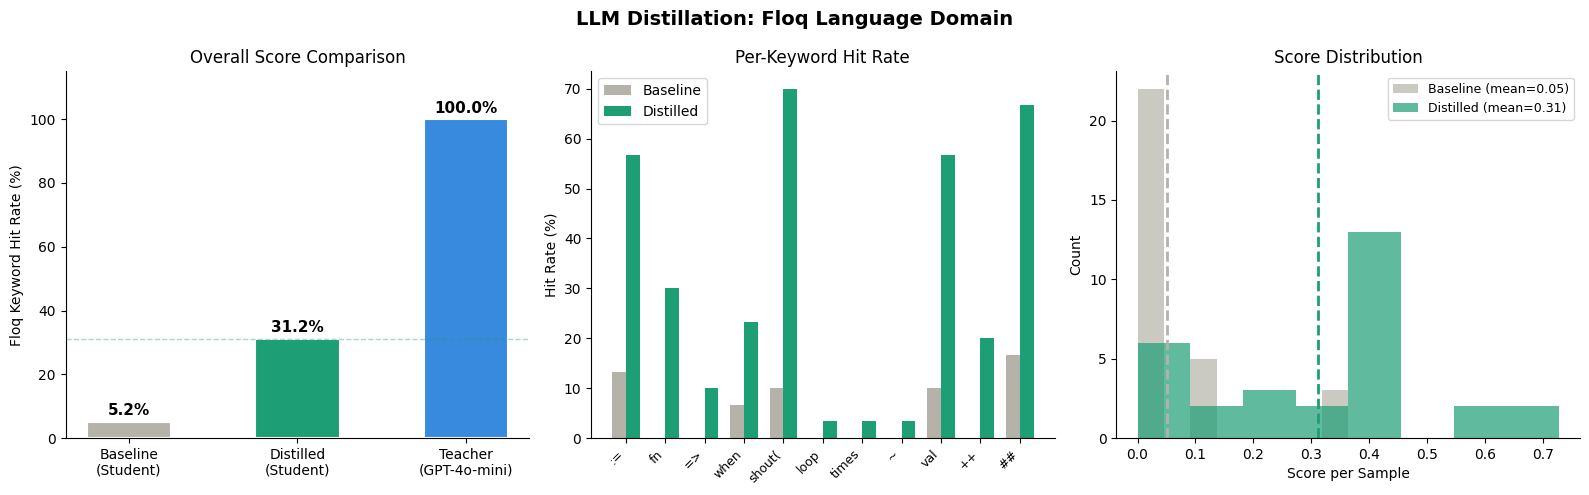

 Figures has been saved to /content/distillation_results.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("LLM Distillation: Floq Language Domain", fontsize=14, fontweight="bold")

colors = {"baseline": "#B4B2A9", "distilled": "#1D9E75", "teacher": "#378ADD"}

# Fig 1: Overall Score Comparison
ax1 = axes[0]
models = ["Baseline\n(Student)", "Distilled\n(Student)", "Teacher\n(GPT-4o-mini)"]
scores = [baseline_avg, distilled_avg, 1.0]  # The teacher considers this full marks.
bars = ax1.bar(models, [s*100 for s in scores],
               color=[colors["baseline"], colors["distilled"], colors["teacher"]],
               width=0.5, edgecolor="white", linewidth=1.5)
for bar, score in zip(bars, scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{score*100:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax1.set_ylim(0, 115)
ax1.set_ylabel("Floq Keyword Hit Rate (%)")
ax1.set_title("Overall Score Comparison")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.axhline(y=distilled_avg*100, color=colors["distilled"], linestyle="--", alpha=0.4, linewidth=1)

# Fig 2: Keyword Hit Rate Breakdown
ax2 = axes[1]
kws = list(FLOQ_KEYWORDS)
n = len(test_data)
baseline_rates = [baseline_kw.get(kw,0)/n for kw in kws]
distilled_rates = [distilled_kw.get(kw,0)/n for kw in kws]
x = np.arange(len(kws))
w = 0.35
ax2.bar(x - w/2, [r*100 for r in baseline_rates],  w, label="Baseline",  color=colors["baseline"])
ax2.bar(x + w/2, [r*100 for r in distilled_rates], w, label="Distilled", color=colors["distilled"])
ax2.set_xticks(x)
ax2.set_xticklabels([kw.strip() for kw in kws], rotation=45, ha="right", fontsize=9)
ax2.set_ylabel("Hit Rate (%)")
ax2.set_title("Per-Keyword Hit Rate")
ax2.legend()
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Fig 3: Score Distribution for Each Test Item
ax3 = axes[2]
ax3.hist(baseline_scores,  bins=8, alpha=0.7, color=colors["baseline"],  label=f"Baseline (mean={baseline_avg:.2f})")
ax3.hist(distilled_scores, bins=8, alpha=0.7, color=colors["distilled"], label=f"Distilled (mean={distilled_avg:.2f})")
ax3.axvline(baseline_avg,  color=colors["baseline"],  linestyle="--", linewidth=2)
ax3.axvline(distilled_avg, color=colors["distilled"], linestyle="--", linewidth=2)
ax3.set_xlabel("Score per Sample")
ax3.set_ylabel("Count")
ax3.set_title("Score Distribution")
ax3.legend(fontsize=9)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("/content/distillation_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Figures has been saved to /content/distillation_results.png")

In [18]:
# Final  Repo
improvement = (distilled_avg - baseline_avg) / max(baseline_avg, 1e-6) * 100

print("=" * 55)
print("          Results Report")
print("=" * 55)
print(f"  Topic:           Fictional Programming Language Floq")
print(f"  Teacher:        OpenAI (gpt-4o-mini)")
print(f"  Student:        Qwen2.5-0.5B-Instruct + LoRA")
print(f"  Training Data Volume:     {len(train_data)} items")
print(f"  Training Data Volume:     {len(test_data)} items")
print("-" * 55)
print(f"  Baseline Score:  {baseline_avg*100:.1f}%  (Before Distillation)")
print(f"  Distilled Score: {distilled_avg*100:.1f}%  (After distillation)")
print(f"  Increase:       +{improvement:.1f}%")
print("-" * 55)

          Results Report
  Topic:           Fictional Programming Language Floq
  Teacher:        OpenAI (gpt-4o-mini)
  Student:        Qwen2.5-0.5B-Instruct + LoRA
  Training Data Volume:     200 items
  Training Data Volume:     30 items
-------------------------------------------------------
  Baseline Score:  5.2%  (Before Distillation)
  Distilled Score: 31.2%  (After distillation)
  Increase:       +505.9%
-------------------------------------------------------


---
##  Step 7（Extra）：Reverse Distillation

Utilize a "Student"—already proficient in Floq—to serve as a **new Teacher**; after generating data, feed it to a Large Language Model (LLM) via an API for few-shot learning or fine-tuning.

This section demonstrates **few-shot prompt injection**: enabling the LLM to acquire Floq knowledge from the Student's output through in-context learning.

In [19]:
# Generate few-shot examples using the distilled Student model.
FEW_SHOT_QUESTIONS = [
    "How do you declare a variable in Floq?",
    "How do you define a function in Floq?",
    "What keyword does Floq use for printing?",
    "How do you write a conditional in Floq?",
    "How do you index a list in Floq?",
]

print(" Generate few-shot examples using Student....")
student_examples = []
for q in FEW_SHOT_QUESTIONS:
    ans = student_generate(distilled_model, tokenizer, q, max_new_tokens=150)
    student_examples.append({"q": q, "a": ans})
    print(f"✓ {q[:50]}...")

# few-shot prompt
few_shot_block = "\n".join([
    f"Q: {ex['q']}\nA: {ex['a']}"
    for ex in student_examples
])

FEW_SHOT_SYSTEM = f"""You are learning about the Floq programming language from examples.
Here are some Q&A examples about Floq:

{few_shot_block}

Based on these examples, answer questions about Floq accurately."""

print("\n Few-shot prompt construction complete")

 Generate few-shot examples using Student....


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:589: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


✓ How do you declare a variable in Floq?...
✓ How do you define a function in Floq?...
✓ What keyword does Floq use for printing?...
✓ How do you write a conditional in Floq?...
✓ How do you index a list in Floq?...

 Few-shot prompt construction complete


In [20]:
# Testing Effectiveness

TEST_REVERSE = [
    "Write a Floq program to compute the sum of 1 to 10.",
    "How do you concatenate strings in Floq?",
    "Write a Floq function that checks if a number is positive.",
]

print(" Reverse Distillation Test\n")
print("=" * 60)

for q in TEST_REVERSE:
    # Without Few-Shot
    r_no_few = client.chat.completions.create(
        model="gpt-4o-mini", max_tokens=200,
        messages=[
            {"role": "system", "content": "You are a programming assistant. Answer questions about the Floq language."},
            {"role": "user", "content": q}
        ]
    ).choices[0].message.content

    # With Few-Shot
    r_few = client.chat.completions.create(
        model="gpt-4o-mini", max_tokens=200,
        messages=[
            {"role": "system", "content": FEW_SHOT_SYSTEM},
            {"role": "user", "content": q}
        ]
    ).choices[0].message.content

    score_no  = floq_score(r_no_few)
    score_few = floq_score(r_few)

    print(f"\n❓ {q}")
    print(f"\n  [Without few-shot] Score: {score_no:.2f}")
    print(f"  {r_no_few[:200]}")
    print(f"\n  [With few-shot] Score: {score_few:.2f}")
    print(f"  {r_few[:200]}")

    print("-" * 60)

 Reverse Distillation Test


❓ Write a Floq program to compute the sum of 1 to 10.

  [Without few-shot] Score: 0.09
  Certainly! Below is a simple Floq program that computes the sum of the numbers from 1 to 10.

```floq
start
    sum = 0
    for i = 1 to 10 do
        sum = sum + i
    end for
    output sum
end
```


  [With few-shot] Score: 0.45
  Here’s a simple Floq program that computes the sum of the numbers from 1 to 10:

```floq
## Define a function to calculate the sum of numbers from 1 to n
fn sumTo(n) =>
  val total := 0
  for i in 1 t
------------------------------------------------------------

❓ How do you concatenate strings in Floq?

  [Without few-shot] Score: 0.00
  In Floq, you can concatenate strings using the `+` operator. For example, if you have two strings, `string1` and `string2`, you can concatenate them like this:

```floq
result = string1 + string2;
```

  [With few-shot] Score: 0.36
  In Floq, you can concatenate strings using the `+` operator. Here’s an e

In [21]:
# Quantitative Assessment
from tqdm.auto import tqdm

n_test = min(20, len(test_data))
scores_no_few  = []
scores_with_few = []

print(f" Quantitative Assessment via Reverse Distillation（{n_test} items）...")
for i, item in enumerate(tqdm(test_data[:n_test], desc="Reverse Distillation Evaluation")):
    r_no = client.chat.completions.create(
        model="gpt-4o-mini", max_tokens=150,
        messages=[
            {"role": "system", "content": "You are a programming assistant."},
            {"role": "user", "content": item["instruction"]}
        ]
    ).choices[0].message.content

    r_few = client.chat.completions.create(
        model="gpt-4o-mini", max_tokens=150,
        messages=[
            {"role": "system", "content": FEW_SHOT_SYSTEM},
            {"role": "user", "content": item["instruction"]}
        ]
    ).choices[0].message.content

    scores_no_few.append(floq_score(r_no))
    scores_with_few.append(floq_score(r_few))
    time.sleep(0.1)

avg_no  = sum(scores_no_few) / len(scores_no_few)
avg_few = sum(scores_with_few) / len(scores_with_few)

print("\n" + "=" * 55)
print("   Reverse Distillation Results")
print("=" * 55)
print(f"  LLM (No Knowledge):      {avg_no*100:.1f}%")
print(f"  LLM (Student Injection): {avg_few*100:.1f}%")
print(f"  Increase:                  +{(avg_few-avg_no)*100:.1f}%")
print("=" * 55)

 Quantitative Assessment via Reverse Distillation（20 items）...


Reverse Distillation Evaluation:   0%|          | 0/20 [00:00<?, ?it/s]


   Reverse Distillation Results
  LLM (No Knowledge):      1.8%
  LLM (Student Injection): 27.3%
  Increase:                  +25.5%


---
## Save and Download Results

In [22]:
import zipfile

with zipfile.ZipFile("/content/floq_distillation_results.zip", "w") as zf:
    zf.write("/content/distillation_results.png", "results_chart.png")
    zf.write(str(DATA_PATH / "train.json"), "data/train.json")
    zf.write(str(DATA_PATH / "test.json"),  "data/test.json")

    for f in Path(OUTPUT_DIR).glob("*"):
        zf.write(str(f), f"lora_weights/{f.name}")

print(" Packaged to /content/floq_distillation_results.zip")

from google.colab import files
files.download("/content/floq_distillation_results.zip")

 Packaged to /content/floq_distillation_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>